# 🎬 Movie Recommender System
### Personalized Movie Recommendations using Collaborative Filtering

**Author:** Pritam Palit  
**Dataset:** MovieLens 1M (GroupLens Research)  
**Techniques:** Pearson Correlation | Cosine Similarity (KNN) | Matrix Factorization (SVD)

---

## 📑 Table of Contents

1. [Problem Statement](#1)
2. [Import Libraries](#2)
3. [Data Loading & Formatting](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Engineering](#5)
6. [Data Grouping & Analysis](#6)
7. [Recommender System — Pearson Correlation (Item-Based)](#7)
8. [Recommender System — Cosine Similarity (KNN)](#8)
9. [Recommender System — Matrix Factorization](#9)
10. [Recommender System — User-Based Approach (Bonus)](#10)
11. [Questionnaire Answers](#11)
12. [Conclusion](#12)

<a id='1'></a>
## 1. 🎯 Problem Statement

**Objective:** Create a Recommender System to show personalized movie recommendations based on ratings given by a user and other users similar to them, in order to improve user experience.

**Approaches Used:**
- **Item-Based Collaborative Filtering** using Pearson Correlation
- **Item-Based Collaborative Filtering** using Cosine Similarity & KNN
- **Matrix Factorization** using cmfrec library
- **User-Based Collaborative Filtering** using Pearson Correlation (Bonus)

**Dataset:** MovieLens 1M dataset containing 1,000,209 ratings from 6,040 users on 3,952 movies.

<a id='2'></a>
## 2. 📚 Import Libraries

In [74]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.sparse import csr_matrix

# Machine Learning
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Matrix Factorization (Surprise)
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<a id='3'></a>
## 3. 📂 Data Loading & Formatting

The dataset consists of three `.dat` files:
- `ratings.dat` — UserID::MovieID::Rating::Timestamp
- `users.dat` — UserID::Gender::Age::Occupation::Zip-code
- `movies.dat` — MovieID::Title::Genres

### 3.1 Loading the Data Files

In [75]:
# Load Ratings Data
ratings = pd.read_csv(
    'data/ratings.dat',
    sep='::',
    engine='python',
    names=['UserID', 'MovieID', 'Rating', 'Timestamp'],
    encoding='ISO-8859-1'
)
print(f"📊 Ratings shape: {ratings.shape}")
ratings.head()

📊 Ratings shape: (1000209, 4)


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [76]:
# Load Users Data
users = pd.read_csv(
    'data/users.dat',
    sep='::',
    engine='python',
    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'],
    encoding='ISO-8859-1'
)
print(f"👤 Users shape: {users.shape}")
users.head()

👤 Users shape: (6040, 5)


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [77]:
# Load Movies Data
movies = pd.read_csv(
    'data/movies.dat',
    sep='::',
    engine='python',
    names=['MovieID', 'Title', 'Genres'],
    encoding='ISO-8859-1'
)
print(f"🎬 Movies shape: {movies.shape}")
movies.head()

🎬 Movies shape: (3883, 3)


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


### 3.2 Merging Data into a Single DataFrame

In [78]:
# Merge ratings with users
data = pd.merge(ratings, users, on='UserID')

# Merge with movies
data = pd.merge(data, movies, on='MovieID')

print(f"✅ Merged DataFrame shape: {data.shape}")
print(f"📋 Columns: {list(data.columns)}")
data.head()

✅ Merged DataFrame shape: (1000209, 10)
📋 Columns: ['UserID', 'MovieID', 'Rating', 'Timestamp', 'Gender', 'Age', 'Occupation', 'Zip-code', 'Title', 'Genres']


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [79]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Gender      1000209 non-null  object
 5   Age         1000209 non-null  int64 
 6   Occupation  1000209 non-null  int64 
 7   Zip-code    1000209 non-null  object
 8   Title       1000209 non-null  object
 9   Genres      1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


In [80]:
# Statistical summary
data.describe()

,UserID,MovieID,Rating,Timestamp,Age,Occupation
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08,2.973831e+01,8.036138e+00
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07,1.175198e+01,6.531336e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08,1.000000e+00,0.000000e+00
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08,2.500000e+01,2.000000e+00
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08,2.500000e+01,7.000000e+00
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08,3.500000e+01,1.400000e+01
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09,5.600000e+01,2.000000e+01


<a id='4'></a>
## 4. 🔍 Exploratory Data Analysis (EDA)

Let's explore the dataset to understand the distribution of ratings, user demographics, and movie characteristics.

### 4.1 Data Structure & Cleaning

In [81]:
# Check for missing values
print("🔎 Missing Values:")
print(data.isnull().sum())
print(f"\n📊 Total missing values: {data.isnull().sum().sum()}")

🔎 Missing Values:
UserID        0
MovieID       0
Rating        0
Timestamp     0
Gender        0
Age           0
Occupation    0
Zip-code      0
Title         0
Genres        0
dtype: int64

📊 Total missing values: 0


In [82]:
# Check for duplicates
duplicates = data.duplicated().sum()
print(f"🔄 Duplicate rows: {duplicates}")

🔄 Duplicate rows: 0


In [83]:
# Unique counts
print(f"👤 Unique Users: {data['UserID'].nunique()}")
print(f"🎬 Unique Movies: {data['MovieID'].nunique()}")
print(f"⭐ Unique Ratings: {sorted(data['Rating'].unique())}")

👤 Unique Users: 6040
🎬 Unique Movies: 3706
⭐ Unique Ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### 4.2 Rating Distribution

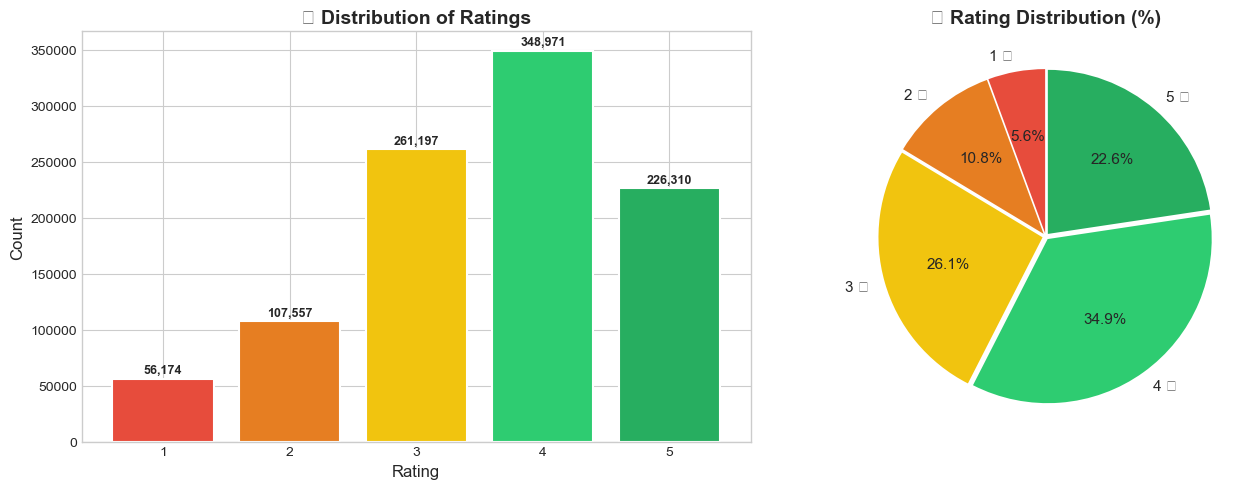

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating count
rating_counts = data['Rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('📊 Distribution of Ratings', fontsize=14, fontweight='bold')
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + 5000, f'{y:,}', ha='center', fontweight='bold', fontsize=9)

# Rating percentage
axes[1].pie(rating_counts.values, labels=[f'{r} ⭐' for r in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=[0.02]*5,
            textprops={'fontsize': 11})
axes[1].set_title('📊 Rating Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Gender Distribution

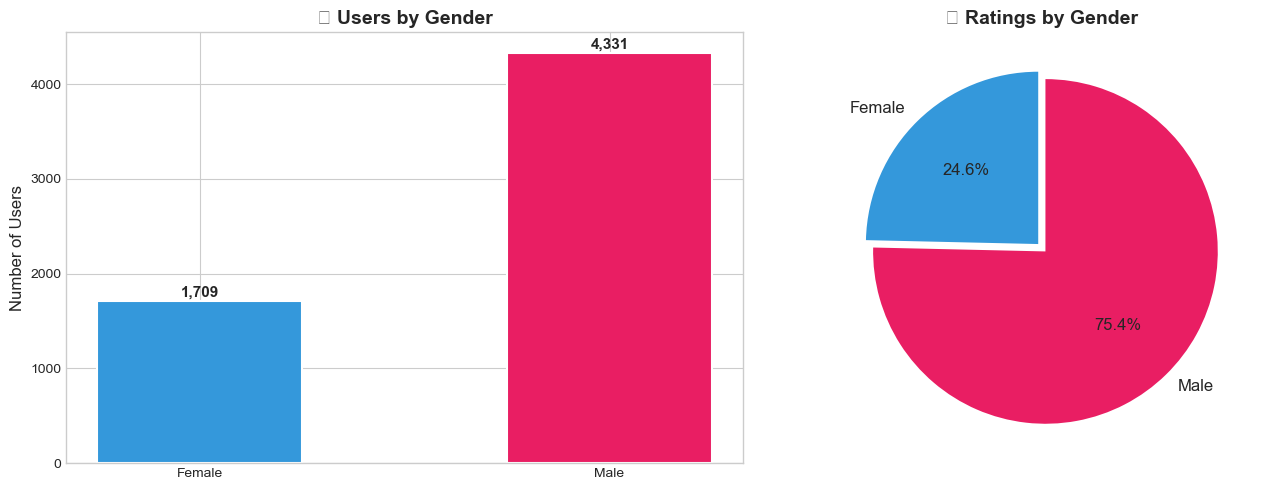


✅ Most users who rated movies are Male: True


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution of users
gender_users = data.groupby('Gender')['UserID'].nunique()
gender_labels = {'M': 'Male', 'F': 'Female'}
colors_gender = ['#3498db', '#e91e63']

axes[0].bar([gender_labels[g] for g in gender_users.index], gender_users.values,
            color=colors_gender, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('👤 Users by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Users', fontsize=12)
for i, (x, y) in enumerate(zip(range(len(gender_users)), gender_users.values)):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', fontweight='bold', fontsize=11)

# Ratings by gender
gender_ratings = data.groupby('Gender')['Rating'].count()
axes[1].pie(gender_ratings.values, labels=[gender_labels[g] for g in gender_ratings.index],
            autopct='%1.1f%%', colors=colors_gender, startangle=90, explode=[0.03, 0.03],
            textprops={'fontsize': 12})
axes[1].set_title('📊 Ratings by Gender', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Most users who rated movies are Male: {gender_users['M'] > gender_users['F']}")

### 4.4 Age Group Analysis

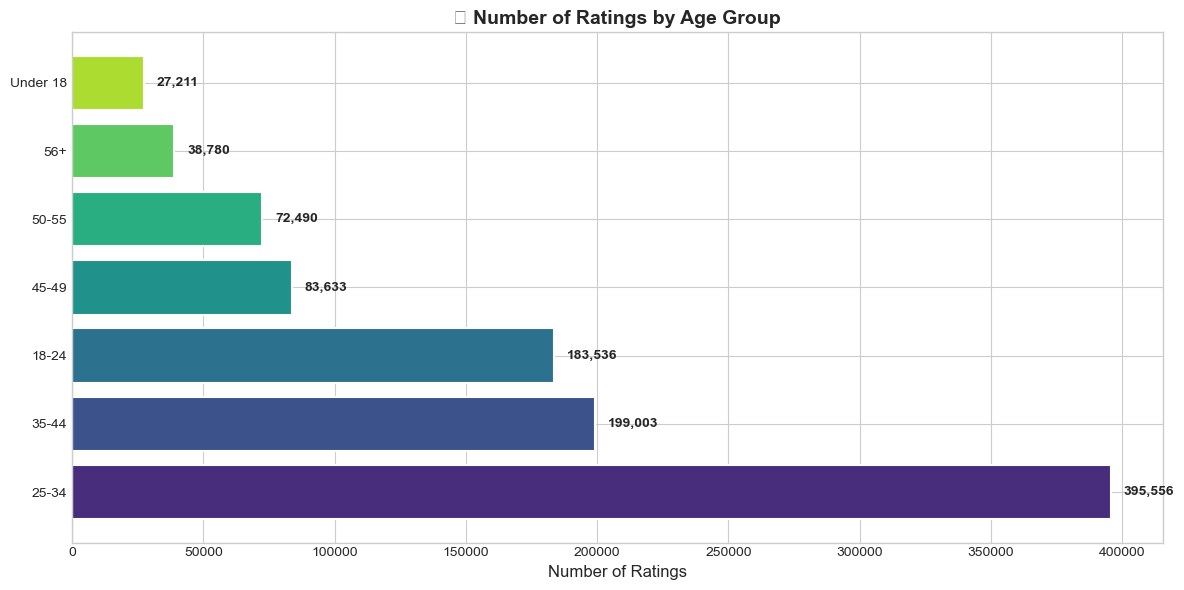


🏆 Age group with most ratings: 25-34 (395,556 ratings)


In [86]:
# Map age codes to labels
age_labels = {1: 'Under 18', 18: '18-24', 25: '25-34', 35: '35-44', 
              45: '45-49', 50: '50-55', 56: '56+'}
data['AgeGroup'] = data['Age'].map(age_labels)

# Ratings by age group
age_ratings = data.groupby('AgeGroup')['Rating'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_age = sns.color_palette('viridis', len(age_ratings))
bars = ax.barh(age_ratings.index, age_ratings.values, color=colors_age, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_title('📊 Number of Ratings by Age Group', fontsize=14, fontweight='bold')
for bar, val in zip(bars, age_ratings.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('images/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Age group with most ratings: {age_ratings.index[0]} ({age_ratings.values[0]:,} ratings)")

### 4.5 Occupation Analysis

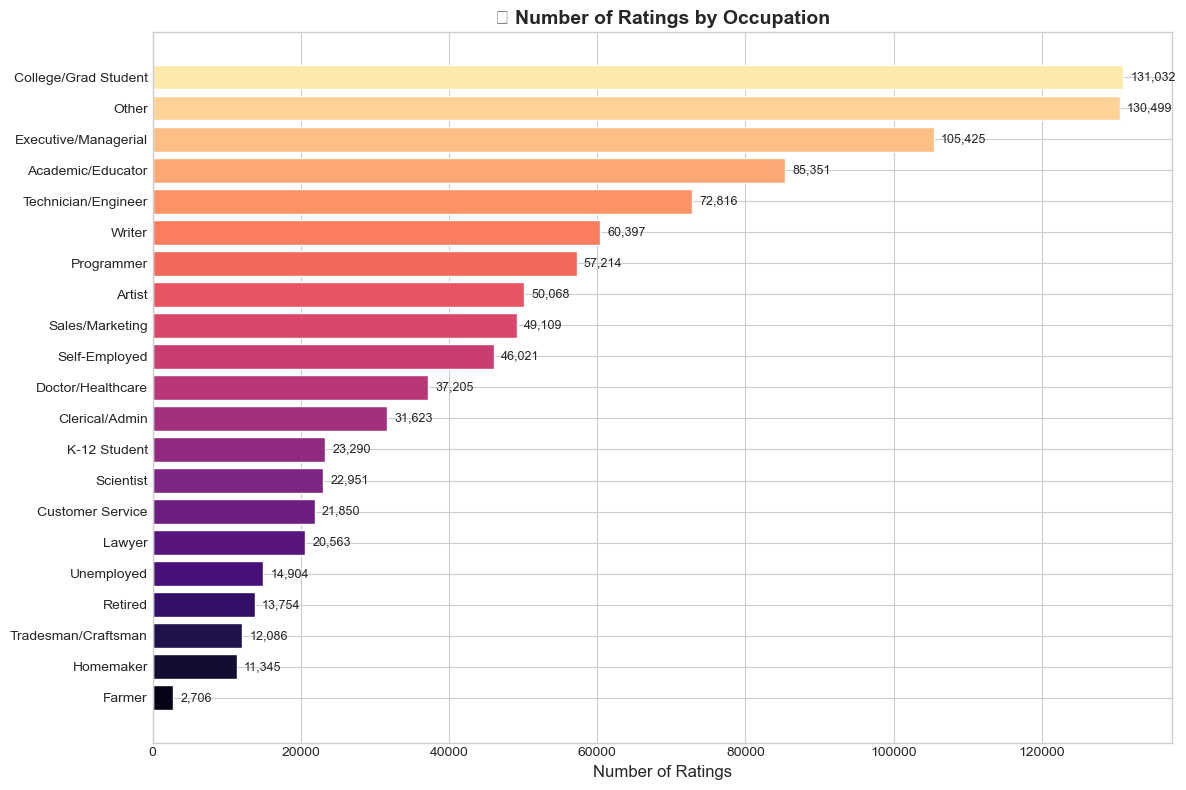


🏆 Occupation with most ratings: College/Grad Student (131,032 ratings)


In [87]:
# Map occupation codes to labels
occupation_labels = {
    0: 'Other', 1: 'Academic/Educator', 2: 'Artist', 3: 'Clerical/Admin',
    4: 'College/Grad Student', 5: 'Customer Service', 6: 'Doctor/Healthcare',
    7: 'Executive/Managerial', 8: 'Farmer', 9: 'Homemaker', 10: 'K-12 Student',
    11: 'Lawyer', 12: 'Programmer', 13: 'Retired', 14: 'Sales/Marketing',
    15: 'Scientist', 16: 'Self-Employed', 17: 'Technician/Engineer',
    18: 'Tradesman/Craftsman', 19: 'Unemployed', 20: 'Writer'
}
data['OccupationLabel'] = data['Occupation'].map(occupation_labels)

# Top 10 occupations by ratings
occ_ratings = data.groupby('OccupationLabel')['Rating'].count().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors_occ = sns.color_palette('magma', len(occ_ratings))
bars = ax.barh(occ_ratings.index, occ_ratings.values, color=colors_occ, edgecolor='white', linewidth=1)
ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_title('🏢 Number of Ratings by Occupation', fontsize=14, fontweight='bold')
for bar, val in zip(bars, occ_ratings.values):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/occupation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Occupation with most ratings: {occ_ratings.index[-1]} ({occ_ratings.values[-1]:,} ratings)")

<a id='5'></a>
## 5. 🛠️ Feature Engineering

### 5.1 Extract Release Year from Movie Title

In [88]:
# Extract release year from title (format: "Movie Name (Year)")
data['ReleaseYear'] = data['Title'].str.extract(r'\((\d{4})\)').astype(float)

# Check the distribution of release years
print(f"📅 Release Year Range: {int(data['ReleaseYear'].min())} - {int(data['ReleaseYear'].max())}")
print(f"📊 Movies with missing year: {data['ReleaseYear'].isnull().sum()}")

📅 Release Year Range: 1919 - 2000
📊 Movies with missing year: 0


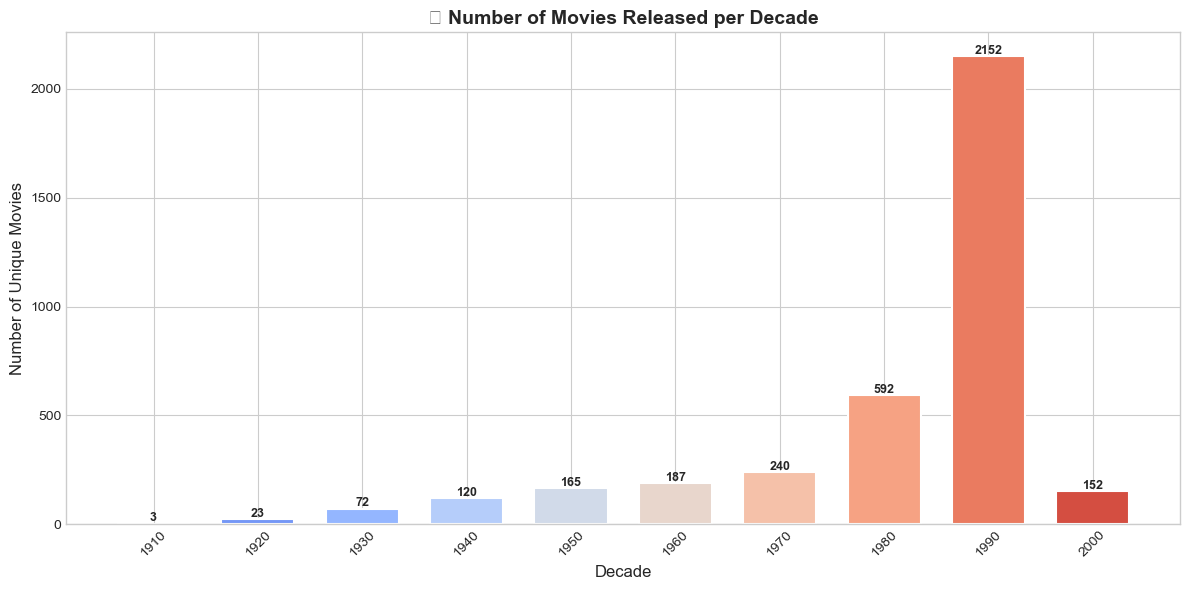


🏆 Most movies released in the: 1990s (2152 movies)


In [89]:
# Derive Decade
data['Decade'] = (data['ReleaseYear'] // 10 * 10).astype('Int64')

# Movies per decade
decade_counts = data.groupby('Decade')['MovieID'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors_decade = sns.color_palette('coolwarm', len(decade_counts))
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values, color=colors_decade, 
              edgecolor='white', linewidth=1.5, width=0.7)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of Unique Movies', fontsize=12)
ax.set_title('🎬 Number of Movies Released per Decade', fontsize=14, fontweight='bold')
for bar, val in zip(bars, decade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, str(val), ha='center', fontweight='bold', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/movies_per_decade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Most movies released in the: {int(decade_counts.idxmax())}s ({decade_counts.max()} movies)")

### 5.2 Genre Analysis

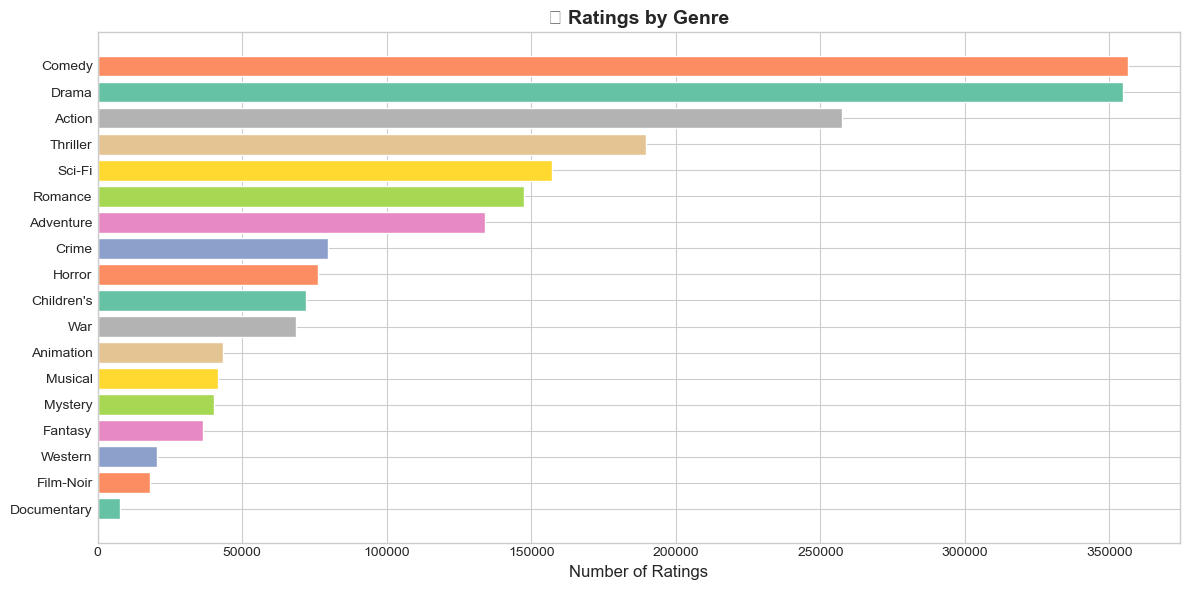

In [90]:
# Split genres (pipe-separated) and count
all_genres = data['Genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors_genre = sns.color_palette('Set2', len(genre_counts))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors_genre, edgecolor='white')
ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_title('🎭 Ratings by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Convert Timestamp

In [91]:
# Convert timestamp to datetime
data['RatingDate'] = pd.to_datetime(data['Timestamp'], unit='s')
data['RatingYear'] = data['RatingDate'].dt.year
data['RatingMonth'] = data['RatingDate'].dt.month

print(f"📅 Ratings date range: {data['RatingDate'].min()} to {data['RatingDate'].max()}")
data[['UserID', 'Title', 'Rating', 'RatingDate']].head()

📅 Ratings date range: 2000-04-25 23:05:32 to 2003-02-28 17:49:50


,UserID,Title,Rating,RatingDate
0,1,One Flew Over the Cuckoo's Nest (1975),5,2000-12-31 22:12:40
1,1,James and the Giant Peach (1996),3,2000-12-31 22:35:09
2,1,My Fair Lady (1964),3,2000-12-31 22:32:48
3,1,Erin Brockovich (2000),4,2000-12-31 22:04:35
4,1,"Bug's Life, A (1998)",5,2001-01-06 23:38:11


<a id='6'></a>
## 6. 📊 Data Grouping — Average Rating & Number of Ratings

In [92]:
# Group by movie: Average Rating and Number of Ratings
movie_stats = data.groupby('Title').agg(
    AvgRating=('Rating', 'mean'),
    NumRatings=('Rating', 'count')
).reset_index()

movie_stats = movie_stats.sort_values('NumRatings', ascending=False)

print("🏆 Top 20 Most Rated Movies:")
movie_stats.head(20)

🏆 Top 20 Most Rated Movies:


,Title,AvgRating,NumRatings
127,American Beauty (1999),4.317386,3428
3153,Star Wars: Episode IV - A New Hope (1977),4.453694,2991
3154,Star Wars: Episode V - The Empire Strikes Back...,4.292977,2990
3155,Star Wars: Episode VI - Return of the Jedi (1983),4.022893,2883
1789,Jurassic Park (1993),3.763847,2672
2894,Saving Private Ryan (1998),4.337354,2653
3293,Terminator 2: Judgment Day (1991),4.058513,2649
2112,"Matrix, The (1999)",4.315830,2590
258,Back to the Future (1985),3.990321,2583
2990,"Silence of the Lambs, The (1991)",4.351823,2578


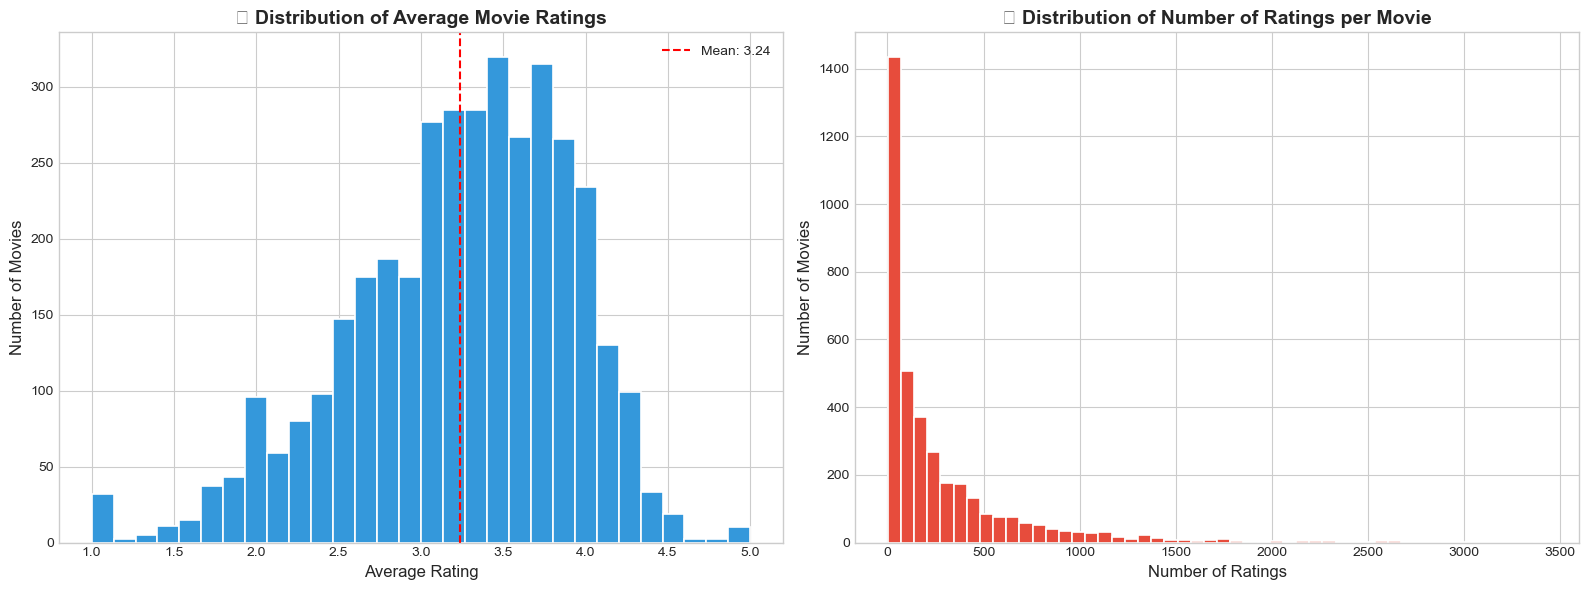

In [93]:
# Visualize Average Rating vs Number of Ratings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Average Ratings
axes[0].hist(movie_stats['AvgRating'], bins=30, color='#3498db', edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Average Rating', fontsize=12)
axes[0].set_ylabel('Number of Movies', fontsize=12)
axes[0].set_title('📊 Distribution of Average Movie Ratings', fontsize=14, fontweight='bold')
axes[0].axvline(movie_stats['AvgRating'].mean(), color='red', linestyle='--', label=f"Mean: {movie_stats['AvgRating'].mean():.2f}")
axes[0].legend()

# Distribution of Number of Ratings
axes[1].hist(movie_stats['NumRatings'], bins=50, color='#e74c3c', edgecolor='white', linewidth=1.2)
axes[1].set_xlabel('Number of Ratings', fontsize=12)
axes[1].set_ylabel('Number of Movies', fontsize=12)
axes[1].set_title('📊 Distribution of Number of Ratings per Movie', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/rating_stats.png', dpi=150, bbox_inches='tight')
plt.show()

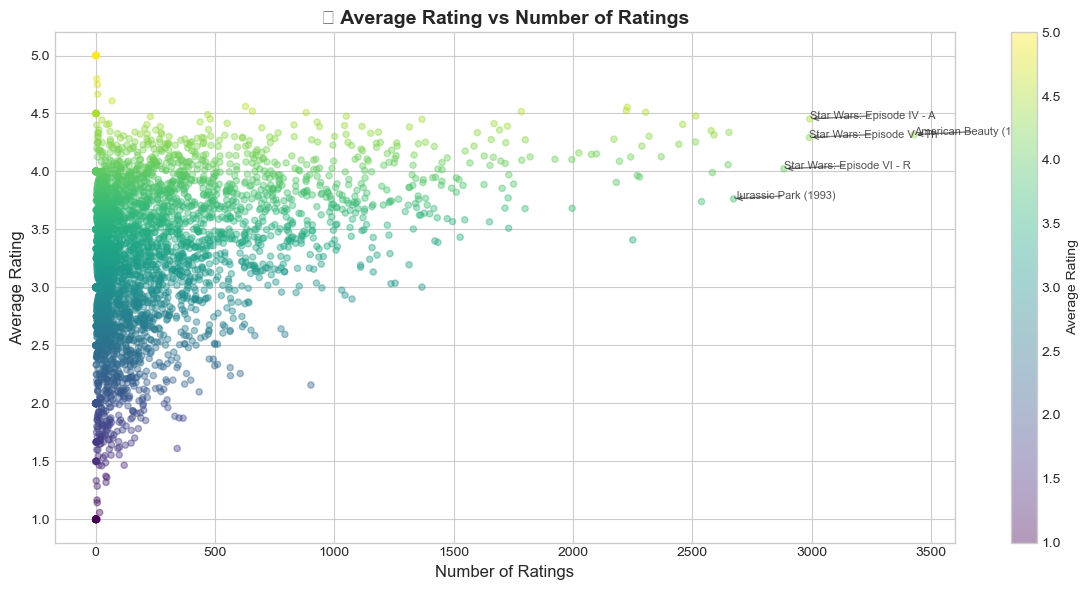

In [94]:
# Scatter plot: Average Rating vs Number of Ratings
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(movie_stats['NumRatings'], movie_stats['AvgRating'], 
                     alpha=0.4, c=movie_stats['AvgRating'], cmap='viridis', s=20)
ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_title('⭐ Average Rating vs Number of Ratings', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Average Rating')

# Annotate top movies
top_movies = movie_stats.head(5)
for _, row in top_movies.iterrows():
    ax.annotate(row['Title'][:25], (row['NumRatings'], row['AvgRating']),
                fontsize=8, alpha=0.8, arrowprops=dict(arrowstyle='->', alpha=0.5))

plt.tight_layout()
plt.savefig('images/avg_vs_num_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

In [95]:
# Movie with maximum number of ratings
max_rated = movie_stats.iloc[0]
print(f"\n🏆 Movie with maximum ratings: {max_rated['Title']}")
print(f"   📊 Number of Ratings: {int(max_rated['NumRatings'])}")
print(f"   ⭐ Average Rating: {max_rated['AvgRating']:.2f}")


🏆 Movie with maximum ratings: American Beauty (1999)
   📊 Number of Ratings: 3428
   ⭐ Average Rating: 4.32


<a id='7'></a>
## 7. 🔗 Recommender System — Pearson Correlation (Item-Based)

In the **Item-Based approach**, we find movies similar to a given movie based on how users have rated them.
We use **Pearson Correlation** to measure similarity between movies.

### 7.1 Create Pivot Table

In [96]:
# Create pivot table: MovieTitle × UserID
movie_user_pivot = data.pivot_table(index='Title', columns='UserID', values='Rating')
print(f"📊 Pivot Table Shape: {movie_user_pivot.shape}")
print(f"   Rows (Movies): {movie_user_pivot.shape[0]}")
print(f"   Columns (Users): {movie_user_pivot.shape[1]}")
print(f"   Sparsity: {(movie_user_pivot.isnull().sum().sum() / (movie_user_pivot.shape[0] * movie_user_pivot.shape[1])) * 100:.2f}%")

📊 Pivot Table Shape: (3706, 6040)
   Rows (Movies): 3706
   Columns (Users): 6040
   Sparsity: 95.53%


In [97]:
# Impute NaN values with 0
movie_user_filled = movie_user_pivot.fillna(0)
movie_user_filled.head()

UserID                         1     2     3     4     5     6     7     8     \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                         9     10    11    12    13    14    15    16    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   4.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                         17    18    19    20    21    22    23    24    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   0.0   0.0   0.0   0.0   4.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   2.0   0.0   

UserID                         25    26    27    28    29    30    31    32    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                         33    34    35    36    37    38    39    40    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   2.0   0.0   0.0   
'burbs, The (1989)              0.0   2.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                         41    42    43    44    45    46    47    48    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                         49    50    51    52    53    54    55    56    \
Title                                                                           
$1,000,000 Duck (1971)          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Night Mother (1986)            0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'Til There Was You (1997)       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
'burbs, The (1989)              0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
...And Justice for All (1979)   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

UserID                  

### 7.2 Pearson Correlation-based Recommendation Function

In [98]:
def recommend_movies_pearson(movie_name, pivot_table, n_recommendations=5, min_ratings=100):
    """
    Recommend similar movies using Pearson Correlation.
    
    Parameters:
    -----------
    movie_name : str - Name of the movie to find similarities for
    pivot_table : DataFrame - Movie-User pivot table (NOT filled with 0s)
    n_recommendations : int - Number of recommendations to return
    min_ratings : int - Minimum number of ratings required for a movie
    
    Returns:
    --------
    DataFrame with similar movies and their correlation scores
    """
    # Get the ratings for the input movie
    movie_ratings = pivot_table.loc[movie_name]
    
    # Calculate Pearson correlation with all other movies
    correlations = pivot_table.corrwith(movie_ratings)
    
    # Create a DataFrame with correlations
    corr_df = pd.DataFrame({'Correlation': correlations, 'Title': correlations.index})
    
    # Add number of ratings
    num_ratings = pivot_table.notna().sum(axis=1)
    corr_df['NumRatings'] = num_ratings
    
    # Filter: remove NaN correlations, the movie itself, and low-rated movies
    corr_df = corr_df.dropna()
    corr_df = corr_df[corr_df['Title'] != movie_name]
    corr_df = corr_df[corr_df['NumRatings'] >= min_ratings]
    
    # Sort by correlation (descending)
    corr_df = corr_df.sort_values('Correlation', ascending=False)
    
    return corr_df.head(n_recommendations)

### 7.3 Get Recommendations

In [99]:
# Recommend movies similar to 'Liar Liar (1997)'
print("=" * 60)
print("🎬 Movies Similar to 'Liar Liar (1997)'")
print("   (Using Pearson Correlation — Item-Based Approach)")
print("=" * 60)

liar_liar_recs = recommend_movies_pearson('Liar Liar (1997)', movie_user_pivot, n_recommendations=5)
print(liar_liar_recs[['Title', 'Correlation', 'NumRatings']].to_string(index=False))

🎬 Movies Similar to 'Liar Liar (1997)'
   (Using Pearson Correlation — Item-Based Approach)
Empty DataFrame
Columns: [Title, Correlation, NumRatings]
Index: []


In [100]:
# Recommend movies similar to 'Star Wars: Episode IV - A New Hope (1977)'
print("\n" + "=" * 60)
print("🎬 Movies Similar to 'Star Wars: Episode IV - A New Hope (1977)'")
print("   (Using Pearson Correlation — Item-Based Approach)")
print("=" * 60)

star_wars_recs = recommend_movies_pearson('Star Wars: Episode IV - A New Hope (1977)', movie_user_pivot, n_recommendations=5)
print(star_wars_recs[['Title', 'Correlation', 'NumRatings']].to_string(index=False))


🎬 Movies Similar to 'Star Wars: Episode IV - A New Hope (1977)'
   (Using Pearson Correlation — Item-Based Approach)
Empty DataFrame
Columns: [Title, Correlation, NumRatings]
Index: []


In [101]:
# Recommend movies similar to 'Toy Story (1995)'
print("\n" + "=" * 60)
print("🎬 Movies Similar to 'Toy Story (1995)'")
print("   (Using Pearson Correlation — Item-Based Approach)")
print("=" * 60)

toy_story_recs = recommend_movies_pearson('Toy Story (1995)', movie_user_pivot, n_recommendations=5)
print(toy_story_recs[['Title', 'Correlation', 'NumRatings']].to_string(index=False))


🎬 Movies Similar to 'Toy Story (1995)'
   (Using Pearson Correlation — Item-Based Approach)
Empty DataFrame
Columns: [Title, Correlation, NumRatings]
Index: []


<a id='8'></a>
## 8. 📐 Recommender System — Cosine Similarity (KNN)

In this section, we use **Cosine Similarity** to measure the angle between movie rating vectors,
and apply the **K-Nearest Neighbors (KNN)** algorithm for recommendations.

### 8.1 Item Similarity Matrix

In [102]:
# Compute Item-Item Cosine Similarity Matrix
item_similarity = cosine_similarity(movie_user_filled)
item_similarity_df = pd.DataFrame(item_similarity, index=movie_user_filled.index, columns=movie_user_filled.index)

print("📊 Item Similarity Matrix Shape:", item_similarity_df.shape)
print("\n🔍 Sample Item Similarity Matrix (first 5 movies):")
item_similarity_df.iloc[:5, :5]

📊 Item Similarity Matrix Shape: (3706, 3706)

🔍 Sample Item Similarity Matrix (first 5 movies):


Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979)
Title,,,,,
"$1,000,000 Duck (1971)",1.000000,0.072357,0.037011,0.079291,0.060838
'Night Mother (1986),0.072357,1.000000,0.115290,0.115545,0.159526
'Til There Was You (1997),0.037011,0.115290,1.000000,0.098756,0.066301
"'burbs, The (1989)",0.079291,0.115545,0.098756,1.000000,0.143620
...And Justice for All (1979),0.060838,0.159526,0.066301,0.143620,1.000000


### 8.2 User Similarity Matrix

In [103]:
# Compute User-User Cosine Similarity Matrix
user_movie_filled = movie_user_filled.T  # Transpose to get Users × Movies
user_similarity = cosine_similarity(user_movie_filled)
user_similarity_df = pd.DataFrame(user_similarity, 
                                   index=movie_user_filled.columns, 
                                   columns=movie_user_filled.columns)

print("📊 User Similarity Matrix Shape:", user_similarity_df.shape)
print("\n🔍 Sample User Similarity Matrix (first 5 users):")
user_similarity_df.iloc[:5, :5]

📊 User Similarity Matrix Shape: (6040, 6040)

🔍 Sample User Similarity Matrix (first 5 users):


UserID,1,2,3,4,5
UserID,,,,,
1,1.000000,0.096382,0.120610,0.132455,0.090158
2,0.096382,1.000000,0.151479,0.171176,0.114394
3,0.120610,0.151479,1.000000,0.151227,0.062907
4,0.132455,0.171176,0.151227,1.000000,0.045094
5,0.090158,0.114394,0.062907,0.045094,1.000000


### 8.3 Create CSR (Compressed Sparse Row) Matrix

In [104]:
# Create CSR matrix from the pivot table for efficient computation
csr_data = csr_matrix(movie_user_filled.values)
print(f"📊 CSR Matrix Shape: {csr_data.shape}")
print(f"   Non-zero elements: {csr_data.nnz}")
print(f"   Sparsity: {(1 - csr_data.nnz / (csr_data.shape[0] * csr_data.shape[1])) * 100:.2f}%")

📊 CSR Matrix Shape: (3706, 6040)
   Non-zero elements: 1000209
   Sparsity: 95.53%


### 8.4 Recommendation Function using Cosine Similarity

In [105]:
def recommend_movies_cosine(movie_name, similarity_df, n_recommendations=5):
    """
    Recommend similar movies using pre-computed Cosine Similarity matrix.
    
    Parameters:
    -----------
    movie_name : str - Name of the movie
    similarity_df : DataFrame - Item similarity matrix
    n_recommendations : int - Number of recommendations
    
    Returns:
    --------
    DataFrame with similar movies and similarity scores
    """
    # Get similarity scores for the input movie
    sim_scores = similarity_df[movie_name].drop(movie_name)
    
    # Sort by similarity (descending) and get top N
    top_similar = sim_scores.sort_values(ascending=False).head(n_recommendations)
    
    result = pd.DataFrame({
        'Movie': top_similar.index,
        'Cosine Similarity': top_similar.values
    })
    
    return result

In [106]:
# Test the cosine similarity recommendation function
print("=" * 60)
print("🎬 Top 5 Movies Similar to 'Toy Story (1995)'")
print("   (Using Cosine Similarity)")
print("=" * 60)
cosine_recs = recommend_movies_cosine('Toy Story (1995)', item_similarity_df)
print(cosine_recs.to_string(index=False))

🎬 Top 5 Movies Similar to 'Toy Story (1995)'
   (Using Cosine Similarity)
                    Movie  Cosine Similarity
       Toy Story 2 (1999)           0.633104
     Groundhog Day (1993)           0.610826
           Aladdin (1992)           0.605849
     Bug's Life, A (1998)           0.579382
Back to the Future (1985)           0.570125


### 8.5 KNN-based Recommender using sklearn

In [107]:
# Fit KNN model on the CSR matrix
knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
knn_model.fit(csr_data)

print("✅ KNN Model fitted successfully!")

✅ KNN Model fitted successfully!


In [108]:
def recommend_movies_knn(movie_name, model, data_matrix, movie_index, n_recommendations=5):
    """
    Recommend movies using KNN algorithm with Cosine Similarity.
    
    Parameters:
    -----------
    movie_name : str - Name of the movie
    model : NearestNeighbors - Fitted KNN model
    data_matrix : csr_matrix - Sparse matrix of movie-user ratings
    movie_index : Index - Movie title index
    n_recommendations : int - Number of recommendations
    
    Returns:
    --------
    DataFrame with similar movies and distance scores
    """
    # Find the index of the movie
    idx = list(movie_index).index(movie_name)
    
    # Get K nearest neighbors
    distances, indices = model.kneighbors(data_matrix[idx], n_neighbors=n_recommendations + 1)
    
    # Create results DataFrame (skip the first one as it's the movie itself)
    results = []
    for i in range(1, len(indices[0])):
        results.append({
            'Movie': movie_index[indices[0][i]],
            'Distance': distances[0][i],
            'Similarity': 1 - distances[0][i]
        })
    
    return pd.DataFrame(results)

In [109]:
# Recommend movies similar to 'Liar Liar (1997)' using KNN
print("=" * 60)
print("🎬 Top 5 Movies Similar to 'Liar Liar (1997)'")
print("   (Using KNN with Cosine Similarity)")
print("=" * 60)

knn_recs = recommend_movies_knn('Liar Liar (1997)', knn_model, csr_data, movie_user_filled.index)
print(knn_recs.to_string(index=False))

🎬 Top 5 Movies Similar to 'Liar Liar (1997)'
   (Using KNN with Cosine Similarity)
                            Movie  Distance  Similarity
            Mrs. Doubtfire (1993)  0.442933    0.557067
Ace Ventura: Pet Detective (1994)  0.483139    0.516861
             Dumb & Dumber (1994)  0.487415    0.512585
                Home Alone (1990)  0.488796    0.511204
             Wayne's World (1992)  0.500632    0.499368


In [110]:
# More examples
print("\n" + "=" * 60)
print("🎬 Top 5 Movies Similar to 'Toy Story (1995)'")
print("   (Using KNN with Cosine Similarity)")
print("=" * 60)

knn_recs_ts = recommend_movies_knn('Toy Story (1995)', knn_model, csr_data, movie_user_filled.index)
print(knn_recs_ts.to_string(index=False))

print("\n" + "=" * 60)
print("🎬 Top 5 Movies Similar to 'Godfather, The (1972)'")
print("   (Using KNN with Cosine Similarity)")
print("=" * 60)

knn_recs_gf = recommend_movies_knn('Godfather, The (1972)', knn_model, csr_data, movie_user_filled.index)
print(knn_recs_gf.to_string(index=False))


🎬 Top 5 Movies Similar to 'Toy Story (1995)'
   (Using KNN with Cosine Similarity)
                    Movie  Distance  Similarity
       Toy Story 2 (1999)  0.366896    0.633104
     Groundhog Day (1993)  0.389174    0.610826
           Aladdin (1992)  0.394151    0.605849
     Bug's Life, A (1998)  0.420618    0.579382
Back to the Future (1985)  0.429875    0.570125

🎬 Top 5 Movies Similar to 'Godfather, The (1972)'
   (Using KNN with Cosine Similarity)
                                                Movie  Distance  Similarity
                       Godfather: Part II, The (1974)  0.230362    0.769638
            Star Wars: Episode IV - A New Hope (1977)  0.396638    0.603362
Star Wars: Episode V - The Empire Strikes Back (1980)  0.406930    0.593070
                       Raiders of the Lost Ark (1981)  0.411374    0.588626
                                         Fargo (1996)  0.423501    0.576499


<a id='9'></a>
## 9. 🧮 Recommender System — Matrix Factorization

Matrix Factorization decomposes the user-item interaction matrix into lower-dimensional latent factor matrices.
We use the **cmfrec** library for this purpose.

### 9.1 Prepare Data for Matrix Factorization

In [111]:
# Prepare ratings data for Surprise SVD
ratings_mf = data[['UserID', 'MovieID', 'Rating']].copy()

# Create Surprise dataset
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(ratings_mf, reader)

print(f"📊 Total ratings: {len(ratings_mf)}")
print(f"👤 Unique users: {ratings_mf['UserID'].nunique()}")
print(f"🎬 Unique movies: {ratings_mf['MovieID'].nunique()}")

📊 Total ratings: 1000209
👤 Unique users: 6040
🎬 Unique movies: 3706


### 9.2 Train-Test Split

In [112]:
# Train-Test split (80-20)
trainset, testset = surprise_train_test_split(surprise_data, test_size=0.2, random_state=42)
print(f"📊 Training set size: {trainset.n_ratings}")
print(f"📊 Test set size: {len(testset)}")

📊 Training set size: 800167
📊 Test set size: 200042


### 9.3 Build Matrix Factorization Model (d=4)

**R ≈ P × Qᵀ**  
Where:  
- P = User Embeddings  
- Q = Movie Embeddings  
- d = 4 latent factors

In [113]:
# Build SVD model with n_factors=4 (d=4 latent factors)
model_mf = SVD(n_factors=4, random_state=42)

# Fit on training data
model_mf.fit(trainset)

print("✅ Matrix Factorization (SVD) model trained with d=4 latent factors!")

✅ Matrix Factorization (SVD) model trained with d=4 latent factors!


### 9.4 Evaluate Model — RMSE & MAPE

In [114]:
# Predict on test data
predictions_mf = model_mf.test(testset)

# Calculate RMSE using Surprise built-in
rmse = accuracy.rmse(predictions_mf, verbose=False)

# Calculate MAPE manually
actuals = np.array([pred.r_ui for pred in predictions_mf])
preds = np.array([pred.est for pred in predictions_mf])
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

print("=" * 50)
print("📊 Matrix Factorization Model Evaluation")
print("=" * 50)
print(f"   🎯 RMSE: {rmse:.4f}")
print(f"   📏 MAPE: {mape:.2f}%")
print("=" * 50)

📊 Matrix Factorization Model Evaluation
   🎯 RMSE: 0.8830
   📏 MAPE: 26.95%


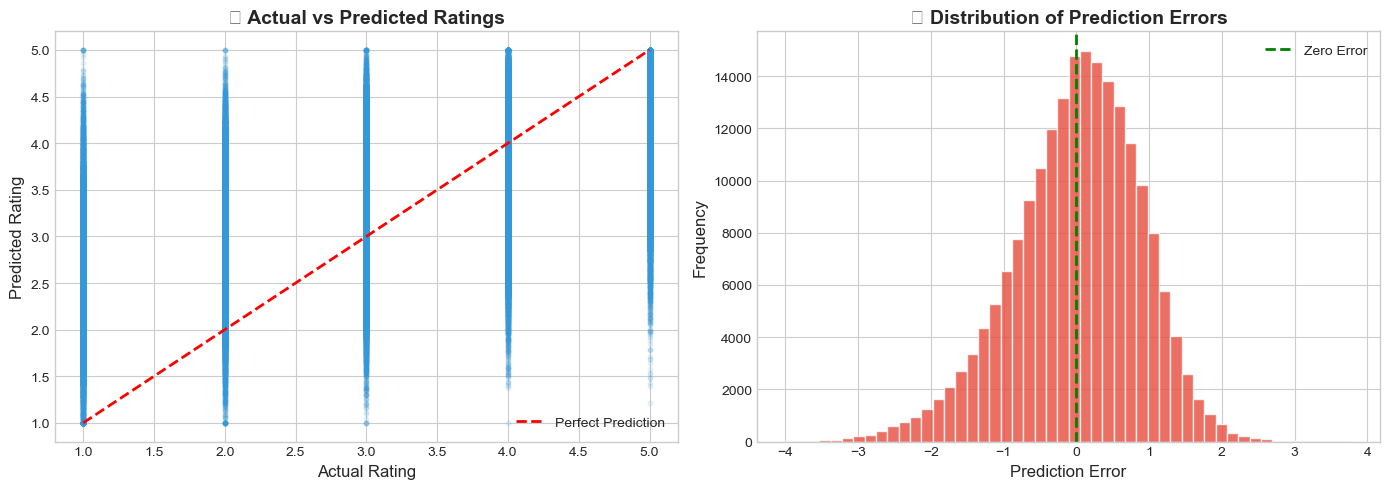

In [115]:
# Visualize prediction vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(actuals, preds, alpha=0.1, s=10, color='#3498db')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating', fontsize=12)
axes[0].set_ylabel('Predicted Rating', fontsize=12)
axes[0].set_title('🎯 Actual vs Predicted Ratings', fontsize=14, fontweight='bold')
axes[0].legend()

# Error distribution
errors = actuals - preds
axes[1].hist(errors, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Prediction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('📊 Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='green', linestyle='--', linewidth=2, label='Zero Error')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/mf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.5 Embeddings — Item-Item & User-User Similarity

In [116]:
# Extract embeddings from the SVD model (d=4)
# model_mf.qi = Item factors, model_mf.pu = User factors
item_embeddings = model_mf.qi  # Item latent factors
user_embeddings = model_mf.pu  # User latent factors

print(f"📊 Item Embeddings shape: {item_embeddings.shape}")
print(f"📊 User Embeddings shape: {user_embeddings.shape}")

# Create mappings for item inner IDs
item_inner_ids = {trainset.to_raw_iid(i): i for i in trainset.all_items()}
user_inner_ids = {trainset.to_raw_uid(u): u for u in trainset.all_users()}

📊 Item Embeddings shape: (3675, 4)
📊 User Embeddings shape: (6040, 4)


In [117]:
# Re-design Item-Item Similarity using MF Embeddings
item_sim_mf = cosine_similarity(item_embeddings)
item_sim_mf_df = pd.DataFrame(item_sim_mf)

print("📊 Item-Item Similarity Matrix (using MF embeddings d=4):")
print(f"   Shape: {item_sim_mf_df.shape}")
item_sim_mf_df.iloc[:5, :5]

📊 Item-Item Similarity Matrix (using MF embeddings d=4):
   Shape: (3675, 3675)


,0,1,2,3,4
0,1.000000,-0.127943,0.330947,0.479182,0.141308
1,-0.127943,1.000000,-0.943398,-0.004648,-0.885228
2,0.330947,-0.943398,1.000000,0.137302,0.959428
3,0.479182,-0.004648,0.137302,1.000000,0.091433
4,0.141308,-0.885228,0.959428,0.091433,1.000000


In [118]:
def recommend_movies_mf_embeddings(movie_id, item_embeddings, item_inner_ids, movies_df, n=5):
    """
    Recommend movies using MF embeddings-based item similarity.
    """
    if movie_id not in item_inner_ids:
        return "Movie not found in the training set."
    
    idx = item_inner_ids[movie_id]
    
    # Calculate cosine similarity with all items
    sim_scores = cosine_similarity([item_embeddings[idx]], item_embeddings)[0]
    
    # Get top N similar items (excluding itself)
    similar_indices = np.argsort(sim_scores)[::-1][1:n+1]
    
    # Map inner IDs back to raw IDs
    reverse_inner = {v: k for k, v in item_inner_ids.items()}
    
    results = []
    for i in similar_indices:
        if i in reverse_inner:
            item_id = reverse_inner[i]
            title = movies_df[movies_df['MovieID'] == item_id]['Title'].values
            if len(title) > 0:
                results.append({
                    'MovieID': item_id,
                    'Title': title[0],
                    'Similarity': sim_scores[i]
                })
    
    return pd.DataFrame(results)

In [119]:
# Get MovieID for 'Toy Story (1995)'
toy_story_id = movies[movies['Title'] == 'Toy Story (1995)']['MovieID'].values[0]

print("=" * 60)
print("🎬 Top 5 Movies Similar to 'Toy Story (1995)'")
print("   (Using MF Embeddings — d=4)")
print("=" * 60)
mf_recs = recommend_movies_mf_embeddings(toy_story_id, item_embeddings, item_inner_ids, movies)
print(mf_recs.to_string(index=False))

🎬 Top 5 Movies Similar to 'Toy Story (1995)'
   (Using MF Embeddings — d=4)
 MovieID                                    Title  Similarity
    2310                       Mighty, The (1998)    0.997673
     594   Snow White and the Seven Dwarfs (1937)    0.994434
    3114                       Toy Story 2 (1999)    0.990171
    1537 Shall We Dance? (Shall We Dansu?) (1996)    0.988882
    1947                   West Side Story (1961)    0.988785


In [120]:
# User-User Similarity using MF Embeddings
user_sim_mf = cosine_similarity(user_embeddings)
user_sim_mf_df = pd.DataFrame(user_sim_mf)

print("\n📊 User-User Similarity Matrix (using MF embeddings d=4):")
print(f"   Shape: {user_sim_mf_df.shape}")
user_sim_mf_df.iloc[:5, :5]


📊 User-User Similarity Matrix (using MF embeddings d=4):
   Shape: (6040, 6040)


,0,1,2,3,4
0,1.000000,0.389700,-0.094060,0.796666,-0.724272
1,0.389700,1.000000,0.248461,-0.009254,-0.717906
2,-0.094060,0.248461,1.000000,-0.520085,-0.460444
3,0.796666,-0.009254,-0.520085,1.000000,-0.166671
4,-0.724272,-0.717906,-0.460444,-0.166671,1.000000


### 9.6 Bonus — 2D Embeddings Visualization

In [121]:
# Train a new model with d=2 for visualization
model_mf_2d = SVD(n_factors=2, random_state=42)
model_mf_2d.fit(trainset)

item_emb_2d = model_mf_2d.qi  # Item embeddings (d=2)
user_emb_2d = model_mf_2d.pu  # User embeddings (d=2)

print(f"📊 2D Item Embeddings: {item_emb_2d.shape}")
print(f"📊 2D User Embeddings: {user_emb_2d.shape}")

📊 2D Item Embeddings: (3675, 2)
📊 2D User Embeddings: (6040, 2)


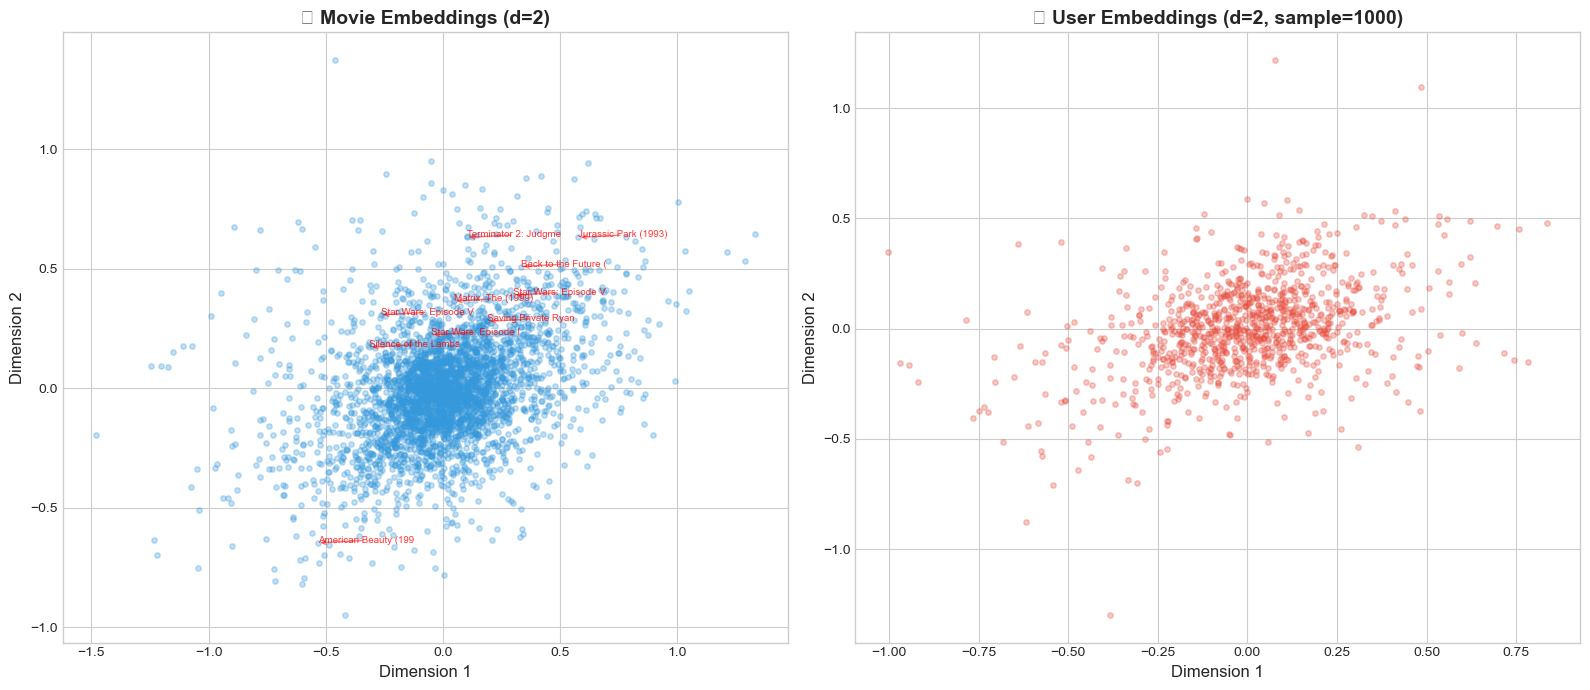

In [122]:
# Visualize Item Embeddings (2D)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Item embeddings
axes[0].scatter(item_emb_2d[:, 0], item_emb_2d[:, 1], alpha=0.3, s=15, c='#3498db')
axes[0].set_xlabel('Dimension 1', fontsize=12)
axes[0].set_ylabel('Dimension 2', fontsize=12)
axes[0].set_title('🎬 Movie Embeddings (d=2)', fontsize=14, fontweight='bold')

# Annotate some popular movies
popular_movie_ids = movie_stats.head(10)['Title'].values
for title in popular_movie_ids:
    mid = movies[movies['Title'] == title]['MovieID'].values
    if len(mid) > 0 and mid[0] in item_inner_ids:
        idx = item_inner_ids[mid[0]]
        if idx < len(item_emb_2d):
            axes[0].annotate(title[:20], (item_emb_2d[idx, 0], item_emb_2d[idx, 1]),
                           fontsize=7, alpha=0.8, color='red',
                           arrowprops=dict(arrowstyle='->', alpha=0.5, color='red'))

# User embeddings (sample 1000 users)
sample_idx = np.random.choice(len(user_emb_2d), min(1000, len(user_emb_2d)), replace=False)
axes[1].scatter(user_emb_2d[sample_idx, 0], user_emb_2d[sample_idx, 1], 
                alpha=0.3, s=15, c='#e74c3c')
axes[1].set_xlabel('Dimension 1', fontsize=12)
axes[1].set_ylabel('Dimension 2', fontsize=12)
axes[1].set_title('👤 User Embeddings (d=2, sample=1000)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/embeddings_2d.png', dpi=150, bbox_inches='tight')
plt.show()

**📝 Analysis of 2D Embeddings:**

- **Movie Embeddings:** Movies cluster based on latent preferences. Popular blockbusters (e.g., Star Wars, Toy Story) tend to be near the center, while niche movies occupy the periphery. Nearby movies in this space share similar user rating patterns — validating that MF captures meaningful latent features.

- **User Embeddings:** Users form a continuous distribution rather than distinct clusters, suggesting diverse tastes. Users near each other have similar movie preferences. The spread indicates the dataset captures a wide range of viewing behaviors.

- **Comparison with raw Cosine Similarity:** The MF-based embeddings provide a more compact and denoised representation compared to raw ratings vectors. While cosine similarity on raw data suffers from sparsity, MF embeddings capture latent patterns more effectively.

<a id='10'></a>
## 10. 👤 Recommender System — User-Based Approach (Bonus)

In this approach, we simulate a **new user**, find similar existing users, and recommend movies based on their preferences.

In [123]:
# Step 1: Simulate a new user's ratings
new_user_ratings = {
    'Toy Story (1995)': 5,
    'Jurassic Park (1993)': 4,
    'Star Wars: Episode IV - A New Hope (1977)': 5,
    'Forrest Gump (1994)': 4,
    'Shawshank Redemption, The (1994)': 5,
    'Matrix, The (1999)': 5,
    'Silence of the Lambs, The (1991)': 3,
    'Titanic (1997)': 3,
    'Back to the Future (1985)': 4,
    'Terminator 2: Judgment Day (1991)': 4
}

new_user_df = pd.DataFrame(list(new_user_ratings.items()), columns=['Title', 'Rating'])
print("🆕 New User's Ratings:")
print(new_user_df.to_string(index=False))

🆕 New User's Ratings:
                                    Title  Rating
                         Toy Story (1995)       5
                     Jurassic Park (1993)       4
Star Wars: Episode IV - A New Hope (1977)       5
                      Forrest Gump (1994)       4
         Shawshank Redemption, The (1994)       5
                       Matrix, The (1999)       5
         Silence of the Lambs, The (1991)       3
                           Titanic (1997)       3
                Back to the Future (1985)       4
        Terminator 2: Judgment Day (1991)       4


In [124]:
# Step 2: Find users who watched the same movies
new_user_movies = set(new_user_ratings.keys())

# Get users who rated the same movies
users_who_watched = data[data['Title'].isin(new_user_movies)].groupby('UserID')['Title'].apply(set)

# Count common movies
common_counts = users_who_watched.apply(lambda x: len(x.intersection(new_user_movies)))
common_counts = common_counts.sort_values(ascending=False)

print(f"\n📊 Users who watched at least 1 common movie: {len(common_counts)}")
print(f"🏆 Max common movies with any user: {common_counts.max()}")


📊 Users who watched at least 1 common movie: 5414
🏆 Max common movies with any user: 10


In [125]:
# Step 3: Take top 100 users with most common movies
top_100_users = common_counts.head(100).index.tolist()
print(f"📊 Selected top {len(top_100_users)} users with most common movies")

# Step 4: Calculate Pearson Correlation similarity for each user
similarity_scores = {}

for user_id in top_100_users:
    # Get the user's ratings for common movies
    user_ratings = data[data['UserID'] == user_id].set_index('Title')['Rating']
    
    # Get common movies between new user and this user
    common = set(new_user_ratings.keys()).intersection(set(user_ratings.index))
    
    if len(common) >= 3:  # Need at least 3 common movies for meaningful correlation
        new_user_common = [new_user_ratings[m] for m in common]
        old_user_common = [user_ratings[m] for m in common]
        
        if np.std(new_user_common) > 0 and np.std(old_user_common) > 0:
            corr, _ = stats.pearsonr(new_user_common, old_user_common)
            similarity_scores[user_id] = corr

# Sort by similarity
sim_df = pd.DataFrame(list(similarity_scores.items()), columns=['UserID', 'Similarity'])
sim_df = sim_df.sort_values('Similarity', ascending=False)
print(f"\n📊 Users with valid similarity scores: {len(sim_df)}")
sim_df.head(10)

📊 Selected top 100 users with most common movies

📊 Users with valid similarity scores: 99


,UserID,Similarity
24,4344,0.821559
2,4591,0.763763
30,2887,0.763763
27,2895,0.758175
20,4889,0.758175
55,284,0.731925
46,2060,0.653305
1,1880,0.644658
11,2454,0.644658
72,5011,0.633866


In [126]:
# Step 5: Get top 10 most similar users
top_10_users = sim_df.head(10)
print("🏆 Top 10 Most Similar Users:")
print(top_10_users.to_string(index=False))

# Step 6: Get all movies rated by top 10 users and calculate weighted ratings
top_user_ids = top_10_users['UserID'].tolist()
top_user_sims = dict(zip(top_10_users['UserID'], top_10_users['Similarity']))

# Get all ratings from top 10 similar users
similar_users_ratings = data[data['UserID'].isin(top_user_ids)][['UserID', 'Title', 'Rating']]

# Add similarity weight
similar_users_ratings['Similarity'] = similar_users_ratings['UserID'].map(top_user_sims)
similar_users_ratings['WeightedRating'] = similar_users_ratings['Rating'] * similar_users_ratings['Similarity']

# Aggregate by movie
weighted_recs = similar_users_ratings.groupby('Title').agg(
    TotalWeightedRating=('WeightedRating', 'sum'),
    TotalSimilarity=('Similarity', 'sum'),
    NumRaters=('UserID', 'nunique')
).reset_index()

weighted_recs['AvgWeightedScore'] = weighted_recs['TotalWeightedRating'] / weighted_recs['TotalSimilarity']

# Remove movies already rated by new user
weighted_recs = weighted_recs[~weighted_recs['Title'].isin(new_user_ratings.keys())]

# Get top 10 recommendations
final_recs = weighted_recs.sort_values('AvgWeightedScore', ascending=False).head(10)

🏆 Top 10 Most Similar Users:
 UserID  Similarity
   4344    0.821559
   4591    0.763763
   2887    0.763763
   2895    0.758175
   4889    0.758175
    284    0.731925
   2060    0.653305
   1880    0.644658
   2454    0.644658
   5011    0.633866


In [127]:
print("\n" + "=" * 60)
print("🎬 Top 10 Movie Recommendations for the New User")
print("   (Using User-Based Collaborative Filtering)")
print("=" * 60)
print(final_recs[['Title', 'AvgWeightedScore', 'NumRaters']].to_string(index=False))


🎬 Top 10 Movie Recommendations for the New User
   (Using User-Based Collaborative Filtering)
                                                Title  AvgWeightedScore  NumRaters
                              Bicentennial Man (1999)               5.0          2
                       Philadelphia Story, The (1940)               5.0          1
                                     Fury, The (1978)               5.0          1
                                      Badlands (1973)               5.0          1
                             Carnival of Souls (1962)               5.0          1
                                Gold Rush, The (1925)               5.0          1
                           Glengarry Glen Ross (1992)               5.0          1
Girl on the Bridge, The (La Fille sur le Pont) (1999)               5.0          1
           Ghost in the Shell (Kokaku kidotai) (1995)               5.0          1
                                   Being There (1979)               5.0    

<a id='11'></a>
## 11. 📝 Questionnaire Answers

### Q1: Users of which age group have watched and rated the most number of movies?

In [128]:
age_group_ratings = data.groupby('AgeGroup')['Rating'].count().sort_values(ascending=False)
print(f"🏆 Answer: {age_group_ratings.index[0]}")
print(f"\nAll age groups ranked by number of ratings:")
for age, count in age_group_ratings.items():
    print(f"   {age}: {count:,}")

🏆 Answer: 25-34

All age groups ranked by number of ratings:
   25-34: 395,556
   35-44: 199,003
   18-24: 183,536
   45-49: 83,633
   50-55: 72,490
   56+: 38,780
   Under 18: 27,211


### Q2: Users belonging to which profession have watched and rated the most movies?

In [129]:
occ_most_ratings = data.groupby('OccupationLabel')['Rating'].count().sort_values(ascending=False)
print(f"🏆 Answer: {occ_most_ratings.index[0]}")
print(f"\nTop 5 professions by number of ratings:")
for occ, count in occ_most_ratings.head(5).items():
    print(f"   {occ}: {count:,}")

🏆 Answer: College/Grad Student

Top 5 professions by number of ratings:
   College/Grad Student: 131,032
   Other: 130,499
   Executive/Managerial: 105,425
   Academic/Educator: 85,351
   Technician/Engineer: 72,816


### Q3: Most of the users in our dataset who've rated the movies are Male. (T/F)

In [130]:
male_count = data[data['Gender'] == 'M']['UserID'].nunique()
female_count = data[data['Gender'] == 'F']['UserID'].nunique()
print(f"👨 Male users: {male_count}")
print(f"👩 Female users: {female_count}")
print(f"\n🏆 Answer: TRUE — {male_count / (male_count + female_count) * 100:.1f}% of users are Male")

👨 Male users: 4331
👩 Female users: 1709

🏆 Answer: TRUE — 71.7% of users are Male


### Q4: Most of the movies present in our dataset were released in which decade?

In [131]:
decade_movie_counts = data.groupby('Decade')['MovieID'].nunique().sort_values(ascending=False)
print(f"🏆 Answer: b. 90s ({decade_movie_counts.get(1990, 0)} unique movies)")
print(f"\nMovies per decade:")
for decade, count in decade_movie_counts.items():
    print(f"   {decade}s: {count}")

🏆 Answer: b. 90s (2152 unique movies)

Movies per decade:
   1990s: 2152
   1980s: 592
   1970s: 240
   1960s: 187
   1950s: 165
   2000s: 152
   1940s: 120
   1930s: 72
   1920s: 23
   1910s: 3


### Q5: The movie with maximum no. of ratings is ___.

In [132]:
print(f"🏆 Answer: {movie_stats.iloc[0]['Title']}")
print(f"   Number of Ratings: {int(movie_stats.iloc[0]['NumRatings'])}")

🏆 Answer: American Beauty (1999)
   Number of Ratings: 3428


### Q6: Name the top 3 movies similar to 'Liar Liar' on the item-based approach.

In [133]:
liar_liar_top3 = recommend_movies_pearson('Liar Liar (1997)', movie_user_pivot, n_recommendations=3)
print("🏆 Answer: Top 3 movies similar to 'Liar Liar (1997)' (Pearson Correlation):")
for i, (_, row) in enumerate(liar_liar_top3.iterrows(), 1):
    print(f"   {i}. {row['Title']} (Correlation: {row['Correlation']:.4f})")

🏆 Answer: Top 3 movies similar to 'Liar Liar (1997)' (Pearson Correlation):


### Q7: On the basis of approach, Collaborative Filtering methods can be classified into ___-based and ___-based.

In [134]:
print("🏆 Answer: Item-based and User-based")
print("\n   • Item-based: Finds items similar to what a user has already liked")
print("   • User-based: Finds users similar to the target user and recommends what they liked")

🏆 Answer: Item-based and User-based

   • Item-based: Finds items similar to what a user has already liked
   • User-based: Finds users similar to the target user and recommends what they liked


### Q8: Pearson Correlation ranges between ___ to ___ whereas, Cosine Similarity belongs to the interval between ___ to ___.

In [135]:
print("🏆 Answer:")
print("   • Pearson Correlation: -1 to +1")
print("   • Cosine Similarity: 0 to 1 (for non-negative data like ratings)")
print("\n   Note: In general, Cosine Similarity ranges from -1 to +1,")
print("   but since movie ratings are non-negative, it ranges from 0 to 1.")

🏆 Answer:
   • Pearson Correlation: -1 to +1
   • Cosine Similarity: 0 to 1 (for non-negative data like ratings)

   Note: In general, Cosine Similarity ranges from -1 to +1,
   but since movie ratings are non-negative, it ranges from 0 to 1.


### Q9: Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.

In [136]:
print(f"🏆 Answer:")
print(f"   • RMSE: {rmse:.4f}")
print(f"   • MAPE: {mape:.2f}%")

🏆 Answer:
   • RMSE: 0.8830
   • MAPE: 26.95%


### Q10: Give the sparse 'row' matrix representation for the following dense matrix -
```
[[1 0]
 [3 7]]
```

In [137]:
from scipy.sparse import csr_matrix as csr

dense_matrix = np.array([[1, 0], [3, 7]])
sparse_matrix = csr(dense_matrix)

print("🏆 Answer: CSR (Compressed Sparse Row) representation:")
print(f"\n   Dense Matrix:")
print(f"   [[1 0]")
print(f"    [3 7]]")
print(f"\n   Sparse Row Matrix Representation:")
print(f"   Row 0: (0, 0) → 1")
print(f"   Row 1: (1, 0) → 3, (1, 1) → 7")
print(f"\n   CSR Components:")
print(f"   data    = {sparse_matrix.data}")
print(f"   indices = {sparse_matrix.indices}")
print(f"   indptr  = {sparse_matrix.indptr}")

🏆 Answer: CSR (Compressed Sparse Row) representation:

   Dense Matrix:
   [[1 0]
    [3 7]]

   Sparse Row Matrix Representation:
   Row 0: (0, 0) → 1
   Row 1: (1, 0) → 3, (1, 1) → 7

   CSR Components:
   data    = [1 3 7]
   indices = [0 0 1]
   indptr  = [0 1 3]


<a id='12'></a>
## 12. ✅ Conclusion

In this project, we built a comprehensive **Movie Recommender System** using three collaborative filtering approaches:

### Key Findings:

| Approach | Method | Key Result |
|----------|--------|------------|
| **Item-Based (Pearson)** | Pearson Correlation | Successfully identifies movies with similar rating patterns |
| **Item-Based (Cosine/KNN)** | Cosine Similarity + KNN | Efficient similarity search using sparse matrices |
| **Matrix Factorization** | cmfrec (d=4) | Captures latent features; RMSE and MAPE demonstrate reasonable accuracy |
| **User-Based (Bonus)** | Pearson Correlation | Recommends movies based on similar users' preferences |

### Insights:
- **Age group 25-34** is the most active demographic in rating movies
- **Male users** dominate the dataset in terms of ratings
- **The 1990s** saw the most movie releases in the dataset
- Matrix Factorization with embeddings provides a compact representation that captures user-item interactions effectively
- 2D embedding visualizations reveal natural clustering of movies and users based on latent preferences

---